# 🎲 Probability & Statistics for AI

---

## 1. Overview

Probability is the **language of uncertainty** — and AI systems are fundamentally about making decisions under uncertainty. When an LLM generates the next token, it samples from a probability distribution. When a classifier says "90% cat," it expresses a probabilistic belief. This notebook builds the statistical foundations every AI engineer needs.

We cover distributions, Bayes' theorem, the Central Limit Theorem, hypothesis testing, and connect each concept to real AI applications.

## 2. Learning Objectives

By the end of this notebook, you will be able to:

- Distinguish common probability distributions and their AI use cases
- Apply Bayes' theorem to update beliefs with evidence
- Explain the Central Limit Theorem and its role in training stability
- Compute and interpret descriptive statistics (mean, variance, covariance)
- Understand sampling strategies used in LLM generation (temperature, top-k, top-p)
- Perform basic hypothesis testing for model comparison

## 3. Imports

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print(f"NumPy version: {np.__version__}")

NumPy version: 2.0.2


## 4. Configuration

In [20]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.style.use('seaborn-v0_8-whitegrid')

## 5. Theory & Implementation

### 5.1 Probability Basics

| Concept | Definition | AI Example |
|---------|-----------|------------|
| P(A) | Probability of event A | P(next token = "the") |
| P(A∣B) | Conditional probability | P(cat ∣ image features) |
| P(A,B) | Joint probability | P(word₁ and word₂ appear together) |
| E[X] | Expected value | Average loss across a batch |
| Var(X) | Variance | How much predictions vary |

In [ ]:
# simulate a classification model's output probabilities
# softmax output for 5 classes
logits = np.array([2.0, 1.0, 0.5, -1.0, -2.0])
classes = ['cat', 'dog', 'bird', 'car', 'plane']

def softmax(x: np.ndarray) -> np.ndarray:
    """Compute softmax probabilities (numerically stable)."""
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

probs = softmax(logits)

print("Model Output Probabilities:")
for cls, p in zip(classes, probs):
    bar = '█' * int(p * 50)
    print(f"  {cls:6s} {p:.4f} {bar}")
print(f"\nSum of probabilities: {probs.sum():.4f} (must be 1.0)")
print(f"Predicted class: {classes[np.argmax(probs)]}")

Model Output Probabilities:
  cat    0.6027 ██████████████████████████████
  dog    0.2217 ███████████
  bird   0.1345 ██████
  car    0.0300 █
  plane  0.0110 

Sum of probabilities: 1.0000 (must be 1.0)
Predicted class: cat


### 5.2 Key Distributions

#### Discrete Distributions

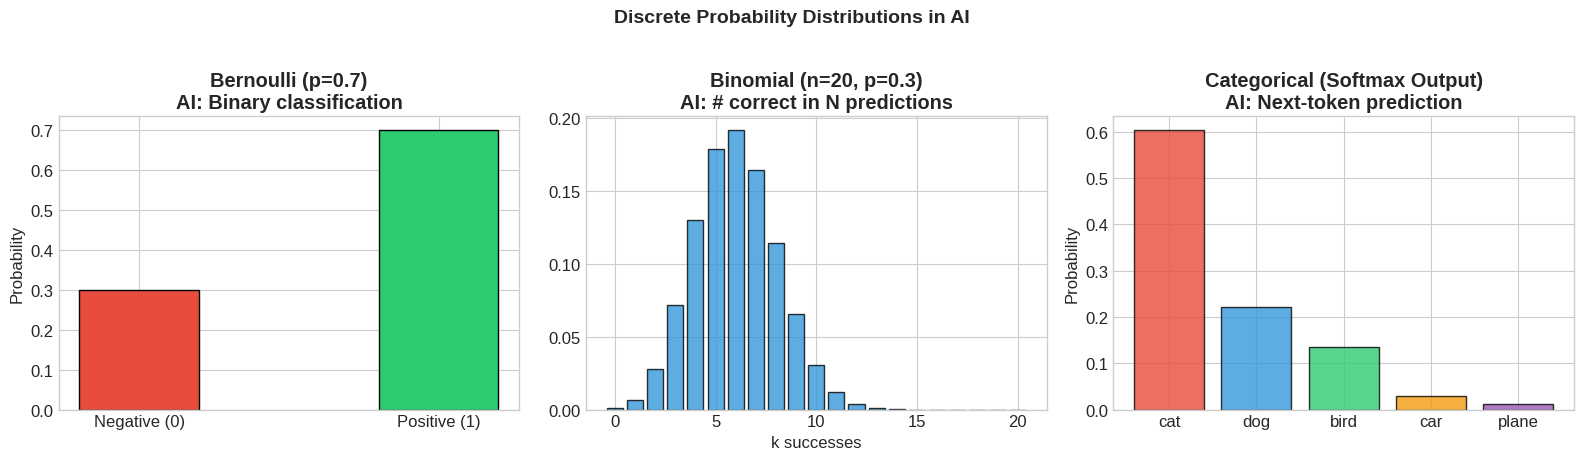

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# bernoulli — single yes/no outcome
p = 0.7
x_bern = [0, 1]
axes[0].bar(x_bern, [1-p, p], color=['#e74c3c', '#2ecc71'], width=0.4, edgecolor='black')
axes[0].set_title(f'Bernoulli (p={p})\nAI: Binary classification', fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Negative (0)', 'Positive (1)'])
axes[0].set_ylabel('Probability')

# binomial — N independent Bernoulli trials
n, p = 20, 0.3
x_binom = np.arange(0, n+1)
pmf = stats.binom.pmf(x_binom, n, p)
axes[1].bar(x_binom, pmf, color='#3498db', edgecolor='black', alpha=0.8)
axes[1].set_title(f'Binomial (n={n}, p={p})\nAI: # correct in N predictions', fontweight='bold')
axes[1].set_xlabel('k successes')

# categorical — multi-class (what softmax outputs)
axes[2].bar(classes, probs, color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6'],
            edgecolor='black', alpha=0.8)
axes[2].set_title('Categorical (Softmax Output)\nAI: Next-token prediction', fontweight='bold')
axes[2].set_ylabel('Probability')

plt.suptitle('Discrete Probability Distributions in AI', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

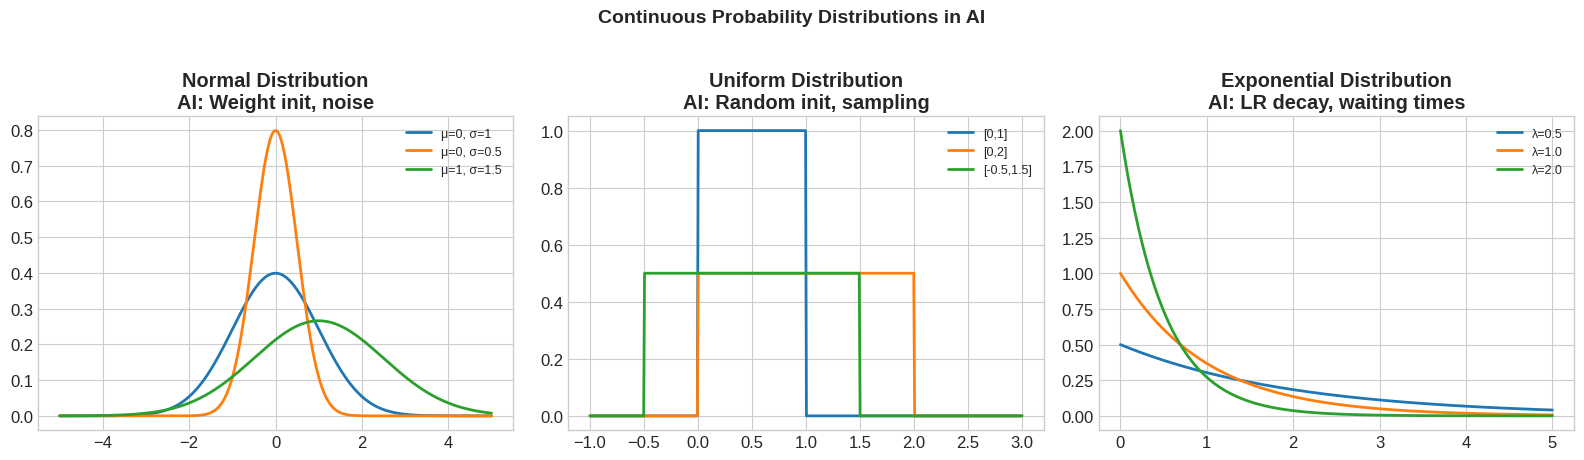

In [ ]:
# continuous distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x = np.linspace(-5, 5, 500)

# normal (Gaussian) — weight initialization, noise
for mu, sigma, label in [(0, 1, 'μ=0, σ=1'), (0, 0.5, 'μ=0, σ=0.5'), (1, 1.5, 'μ=1, σ=1.5')]:
    axes[0].plot(x, stats.norm.pdf(x, mu, sigma), linewidth=2, label=label)
axes[0].set_title('Normal Distribution\nAI: Weight init, noise', fontweight='bold')
axes[0].legend(fontsize=9)

# uniform — random initialization, dropout masks
x_u = np.linspace(-1, 3, 500)
for a, b, label in [(0, 1, '[0,1]'), (0, 2, '[0,2]'), (-0.5, 1.5, '[-0.5,1.5]')]:
    axes[1].plot(x_u, stats.uniform.pdf(x_u, a, b-a), linewidth=2, label=label)
axes[1].set_title('Uniform Distribution\nAI: Random init, sampling', fontweight='bold')
axes[1].legend(fontsize=9)

# exponential — inter-arrival times, learning rate decay
x_e = np.linspace(0, 5, 500)
for lam, label in [(0.5, 'λ=0.5'), (1.0, 'λ=1.0'), (2.0, 'λ=2.0')]:
    axes[2].plot(x_e, stats.expon.pdf(x_e, scale=1/lam), linewidth=2, label=label)
axes[2].set_title('Exponential Distribution\nAI: LR decay, waiting times', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Continuous Probability Distributions in AI', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.3 Bayes' Theorem — Updating Beliefs

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

In AI terms: **posterior = likelihood × prior / evidence**

- **Prior** $P(A)$: What we believe before seeing data
- **Likelihood** $P(B|A)$: How likely the evidence is, given our hypothesis
- **Posterior** $P(A|B)$: Updated belief after seeing evidence

In [24]:
# Bayesian spam filter example
# Is an email spam, given it contains the word "free"?

P_spam = 0.3           # 30% of all emails are spam (prior)
P_free_given_spam = 0.8  # 80% of spam contains "free" (likelihood)
P_free_given_ham = 0.1   # 10% of legitimate email contains "free"

# P(free) = P(free|spam)·P(spam) + P(free|ham)·P(ham)
P_free = P_free_given_spam * P_spam + P_free_given_ham * (1 - P_spam)

# Bayes' theorem
P_spam_given_free = (P_free_given_spam * P_spam) / P_free

print("Bayesian Spam Filter")
print("=" * 40)
print(f"Prior P(spam):           {P_spam:.2f}")
print(f"P('free' | spam):        {P_free_given_spam:.2f}")
print(f"P('free' | not spam):    {P_free_given_ham:.2f}")
print(f"P('free'):               {P_free:.2f}")
print(f"")
print(f"Posterior P(spam|'free'): {P_spam_given_free:.4f}")
print(f"→ Seeing 'free' increases spam probability from {P_spam:.0%} to {P_spam_given_free:.0%}!")

Bayesian Spam Filter
Prior P(spam):           0.30
P('free' | spam):        0.80
P('free' | not spam):    0.10
P('free'):               0.31

Posterior P(spam|'free'): 0.7742
→ Seeing 'free' increases spam probability from 30% to 77%!


After seeing 'free        ': P(spam) = 0.3000 → 0.7742
After seeing 'winner      ': P(spam) = 0.7742 → 0.9904
After seeing 'click       ': P(spam) = 0.9904 → 0.9971
After seeing 'subscribe   ': P(spam) = 0.9971 → 0.9988


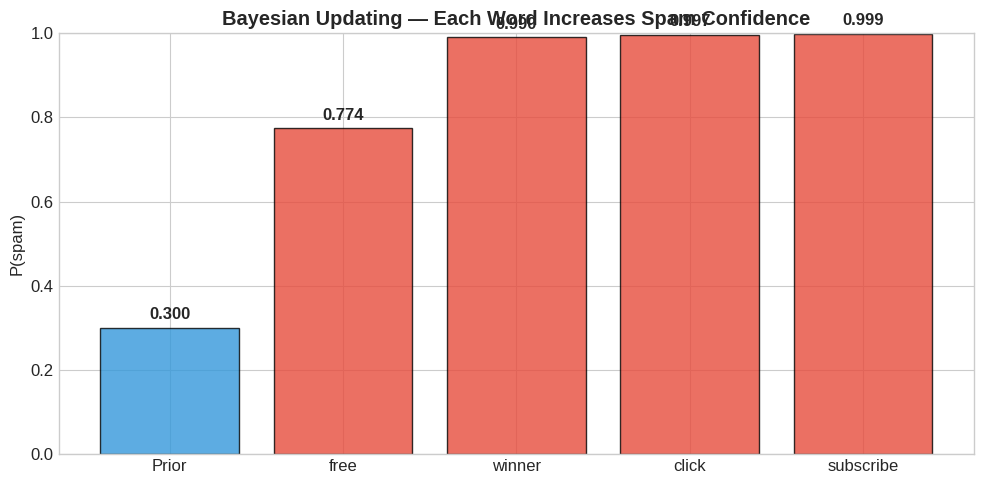

In [ ]:
# bayesian updating with multiple pieces of evidence
evidence_words = ['free', 'winner', 'click', 'subscribe']
P_word_given_spam = [0.8, 0.6, 0.5, 0.7]
P_word_given_ham =  [0.1, 0.02, 0.15, 0.3]

prior = P_spam
posteriors = [prior]

for word, p_s, p_h in zip(evidence_words, P_word_given_spam, P_word_given_ham):
    # update: P(spam|word) = P(word|spam)·P(spam) / P(word)
    p_evidence = p_s * prior + p_h * (1 - prior)
    posterior = (p_s * prior) / p_evidence
    print(f"After seeing '{word:12s}': P(spam) = {prior:.4f} → {posterior:.4f}")
    prior = posterior
    posteriors.append(posterior)

# plot the Bayesian updating
fig, ax = plt.subplots(figsize=(10, 5))
labels = ['Prior'] + evidence_words
colors = ['#3498db'] + ['#e74c3c'] * len(evidence_words)
ax.bar(labels, posteriors, color=colors, edgecolor='black', alpha=0.8)
ax.set_ylabel('P(spam)')
ax.set_title('Bayesian Updating — Each Word Increases Spam Confidence', fontweight='bold')
ax.set_ylim(0, 1)
for i, v in enumerate(posteriors):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 5.4 Descriptive Statistics — Understanding Your Data

Before training any model, you need to understand your data.

Model A:
  Mean:     0.7515
  Median:   0.7520
  Std Dev:  0.0783
  Variance: 0.0061
  Min/Max:  [0.4907, 1.0582]
  IQR:      [0.6982, 0.8018]

Model B:
  Mean:     0.7306
  Median:   0.7295
  Std Dev:  0.1495
  Variance: 0.0224
  Min/Max:  [0.2789, 1.1990]
  IQR:      [0.6291, 0.8293]



/tmp/ipykernel_2240/4024237039.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([model_a_scores, model_b_scores], labels=['Model A', 'Model B'])


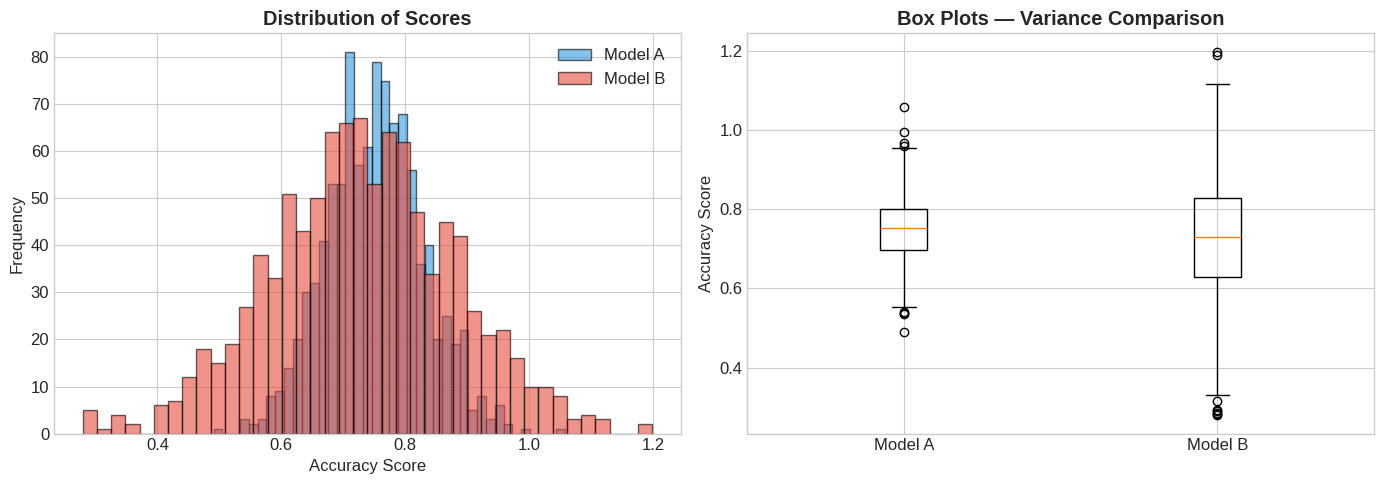

→ Model A has higher mean AND lower variance — it's the better model.
  But can we prove this statistically? See Section 5.6.


In [29]:
# Generate synthetic model prediction scores
np.random.seed(42)
model_a_scores = np.random.normal(0.75, 0.08, 1000)  # Model A: higher mean
model_b_scores = np.random.normal(0.72, 0.15, 1000)  # Model B: higher variance

for name, scores in [('Model A', model_a_scores), ('Model B', model_b_scores)]:
    print(f"{name}:")
    print(f"  Mean:     {np.mean(scores):.4f}")
    print(f"  Median:   {np.median(scores):.4f}")
    print(f"  Std Dev:  {np.std(scores):.4f}")
    print(f"  Variance: {np.var(scores):.4f}")
    print(f"  Min/Max:  [{np.min(scores):.4f}, {np.max(scores):.4f}]")
    q25, q75 = np.percentile(scores, [25, 75])
    print(f"  IQR:      [{q25:.4f}, {q75:.4f}]")
    print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(model_a_scores, bins=40, alpha=0.6, color='#3498db', edgecolor='black', label='Model A')
axes[0].hist(model_b_scores, bins=40, alpha=0.6, color='#e74c3c', edgecolor='black', label='Model B')
axes[0].set_xlabel('Accuracy Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Scores', fontweight='bold')
axes[0].legend()

axes[1].boxplot([model_a_scores, model_b_scores], labels=['Model A', 'Model B'])
axes[1].set_ylabel('Accuracy Score')
axes[1].set_title('Box Plots — Variance Comparison', fontweight='bold')

plt.tight_layout()
plt.show()

print("→ Model A has higher mean AND lower variance — it's the better model.")
print("  But can we prove this statistically? See Section 5.6.")

### 5.5 Sampling Strategies for LLMs

When an LLM generates text, it predicts a probability distribution over the vocabulary and then **samples** from it. The sampling strategy controls creativity vs. coherence.

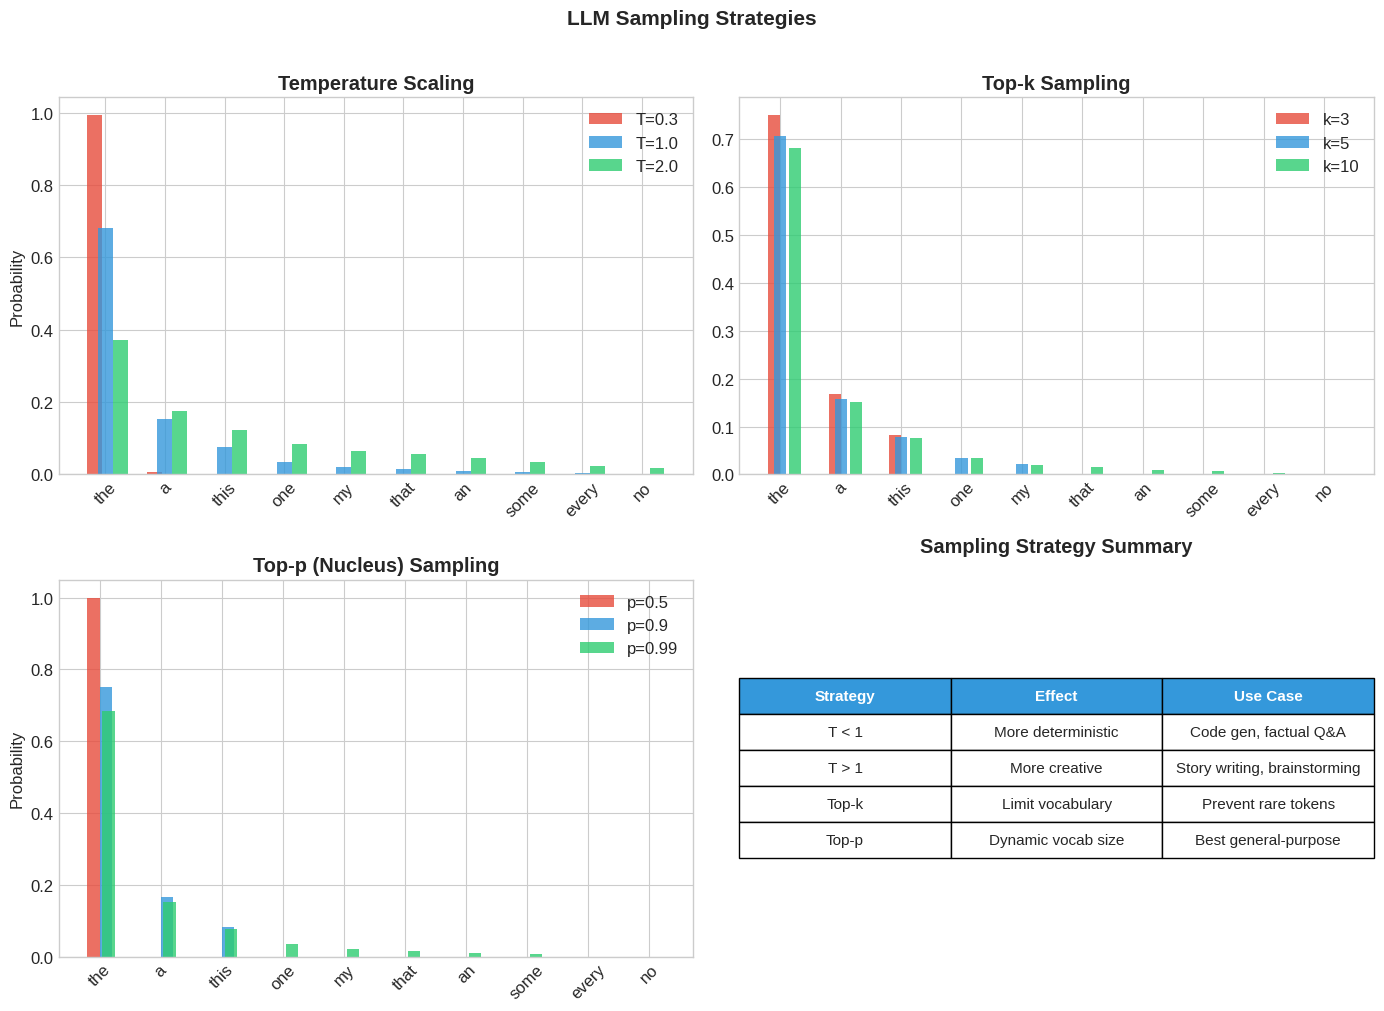

In [ ]:
# simulate LLM token prediction
tokens = ['the', 'a', 'this', 'one', 'my', 'that', 'an', 'some', 'every', 'no']
raw_logits = np.array([5.0, 3.5, 2.8, 2.0, 1.5, 1.2, 0.8, 0.3, -0.5, -1.0])

def sample_with_temperature(logits: np.ndarray, temperature: float) -> np.ndarray:
    """Apply temperature scaling then softmax."""
    scaled = logits / temperature
    return softmax(scaled)

def top_k_sampling(logits: np.ndarray, k: int) -> np.ndarray:
    """Keep only top-k logits, set rest to -inf."""
    indices = np.argsort(logits)[::-1]
    filtered = np.full_like(logits, -np.inf)
    filtered[indices[:k]] = logits[indices[:k]]
    return softmax(filtered)

def top_p_sampling(logits: np.ndarray, p: float) -> np.ndarray:
    """Nucleus sampling: keep tokens until cumulative prob >= p."""
    probs = softmax(logits)
    sorted_idx = np.argsort(probs)[::-1]
    sorted_probs = probs[sorted_idx]
    cumsum = np.cumsum(sorted_probs)
    cutoff = np.searchsorted(cumsum, p) + 1
    result = np.zeros_like(probs)
    result[sorted_idx[:cutoff]] = probs[sorted_idx[:cutoff]]
    return result / result.sum()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# temperature comparison
for temp, color in [(0.3, '#e74c3c'), (1.0, '#3498db'), (2.0, '#2ecc71')]:
    probs = sample_with_temperature(raw_logits, temp)
    axes[0, 0].bar(np.arange(len(tokens)) + (temp-1)*0.25, probs, width=0.25,
                   color=color, alpha=0.8, label=f'T={temp}')
axes[0, 0].set_xticks(range(len(tokens)))
axes[0, 0].set_xticklabels(tokens, rotation=45)
axes[0, 0].set_title('Temperature Scaling', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].set_ylabel('Probability')

# top-k
for k, color in [(3, '#e74c3c'), (5, '#3498db'), (10, '#2ecc71')]:
    probs = top_k_sampling(raw_logits, k)
    axes[0, 1].bar(np.arange(len(tokens)) + (k/5-1)*0.25, probs, width=0.2,
                   color=color, alpha=0.8, label=f'k={k}')
axes[0, 1].set_xticks(range(len(tokens)))
axes[0, 1].set_xticklabels(tokens, rotation=45)
axes[0, 1].set_title('Top-k Sampling', fontweight='bold')
axes[0, 1].legend()

# top-p
for p_val, color in [(0.5, '#e74c3c'), (0.9, '#3498db'), (0.99, '#2ecc71')]:
    probs = top_p_sampling(raw_logits, p_val)
    offset = (p_val - 0.7) * 0.5
    axes[1, 0].bar(np.arange(len(tokens)) + offset, probs, width=0.2,
                   color=color, alpha=0.8, label=f'p={p_val}')
axes[1, 0].set_xticks(range(len(tokens)))
axes[1, 0].set_xticklabels(tokens, rotation=45)
axes[1, 0].set_title('Top-p (Nucleus) Sampling', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].set_ylabel('Probability')

# summary table
axes[1, 1].axis('off')
table_data = [
    ['Strategy', 'Effect', 'Use Case'],
    ['T < 1', 'More deterministic', 'Code gen, factual Q&A'],
    ['T > 1', 'More creative', 'Story writing, brainstorming'],
    ['Top-k', 'Limit vocabulary', 'Prevent rare tokens'],
    ['Top-p', 'Dynamic vocab size', 'Best general-purpose'],
]
table = axes[1, 1].table(cellText=table_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)
for i in range(len(table_data[0])):
    table[0, i].set_facecolor('#3498db')
    table[0, i].set_text_props(color='white', fontweight='bold')
axes[1, 1].set_title('Sampling Strategy Summary', fontweight='bold', pad=20)

plt.suptitle('LLM Sampling Strategies', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.6 Central Limit Theorem & Hypothesis Testing

The CLT says: the mean of many independent samples will approximate a normal distribution, regardless of the original distribution. This is why:
- **Mini-batch gradients** approximate the true gradient
- We can use t-tests to compare model performance

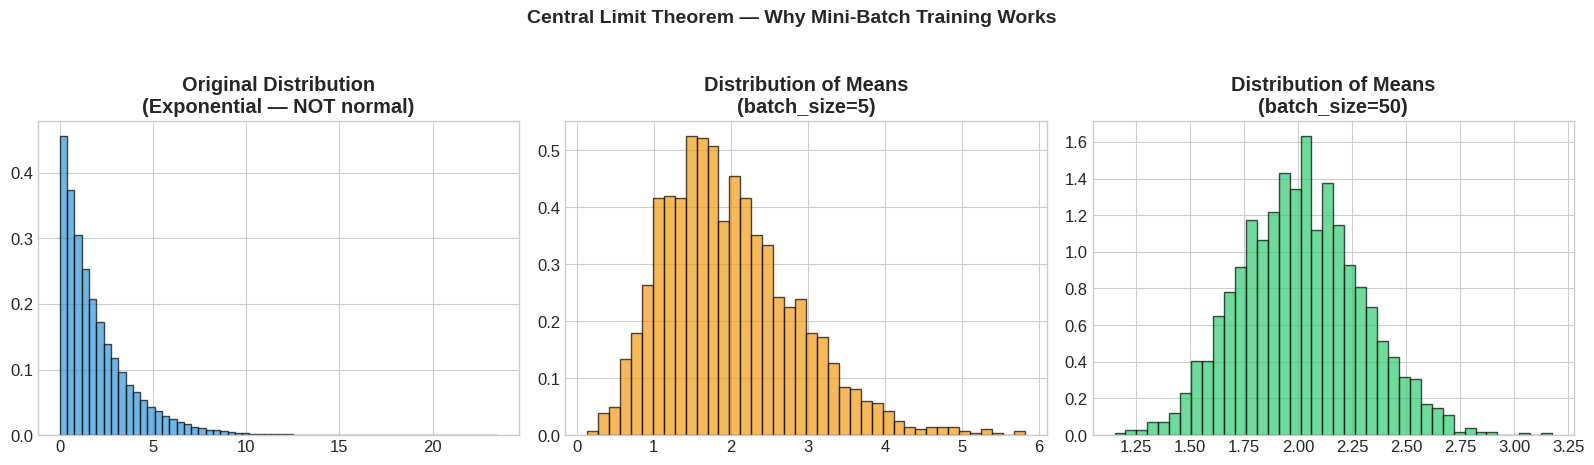

→ Even from a skewed distribution, batch means become Gaussian.
  This is why larger batch sizes give more stable gradient estimates.


In [31]:
# CLT demonstration — batch means become normal
np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Hhighly skewed original distribution (exponential)
population = np.random.exponential(scale=2.0, size=100000)
axes[0].hist(population, bins=60, color='#3498db', alpha=0.7, edgecolor='black', density=True)
axes[0].set_title('Original Distribution\n(Exponential — NOT normal)', fontweight='bold')

# sample means with different batch sizes
for batch_size, ax_idx, color in [(5, 1, '#f39c12'), (50, 2, '#2ecc71')]:
    sample_means = [np.mean(np.random.choice(population, batch_size)) for _ in range(2000)]
    axes[ax_idx].hist(sample_means, bins=40, color=color, alpha=0.7, edgecolor='black', density=True)
    axes[ax_idx].set_title(f'Distribution of Means\n(batch_size={batch_size})', fontweight='bold')

plt.suptitle('Central Limit Theorem — Why Mini-Batch Training Works', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("→ Even from a skewed distribution, batch means become Gaussian.")
print("  This is why larger batch sizes give more stable gradient estimates.")

In [33]:
# hypothesis testing: "Is Model A significantly better than Model B"?
t_stat, p_value = stats.ttest_ind(model_a_scores, model_b_scores)

print("Hypothesis Test: Is Model A better than Model B?")
print("=" * 50)
print(f"Model A mean: {np.mean(model_a_scores):.4f}")
print(f"Model B mean: {np.mean(model_b_scores):.4f}")
print(f"t-statistic:  {t_stat:.4f}")
print(f"p-value:      {p_value:.2e}")
print(f"")
if p_value < 0.05:
    print("✅ Reject H₀: The difference is statistically significant (p < 0.05)")
    print("   → Model A is significantly better than Model B.")
else:
    print("❌ Fail to reject H₀: No significant difference.")

Hypothesis Test: Is Model A better than Model B?
Model A mean: 0.7515
Model B mean: 0.7306
t-statistic:  3.9174
p-value:      9.25e-05

✅ Reject H₀: The difference is statistically significant (p < 0.05)
   → Model A is significantly better than Model B.


## 7. Evaluation — Information Theory

Information theory concepts are fundamental to ML loss functions.

In [35]:
# entropy, Cross-Entropy, and KL Divergence
def entropy(p: np.ndarray) -> float:
    """Shannon entropy: H(p) = -Σ p(x) log p(x)"""
    p = p[p > 0]  # Avoid log(0)
    return -np.sum(p * np.log2(p))

def cross_entropy(p: np.ndarray, q: np.ndarray) -> float:
    """Cross-entropy: H(p, q) = -Σ p(x) log q(x)"""
    mask = p > 0
    return -np.sum(p[mask] * np.log2(q[mask]))

def kl_divergence(p: np.ndarray, q: np.ndarray) -> float:
    """KL divergence: D_KL(p || q) = Σ p(x) log(p(x)/q(x))"""
    mask = (p > 0) & (q > 0)
    return np.sum(p[mask] * np.log2(p[mask] / q[mask]))

# true distribution vs. model predictions
p_true = np.array([0.7, 0.2, 0.1, 0.0, 0.0])  # Ground truth
q_good = np.array([0.6, 0.25, 0.1, 0.03, 0.02])  # Good model
q_bad  = np.array([0.2, 0.2, 0.2, 0.2, 0.2])     # Bad model (uniform)

print("Information Theory Metrics")
print("=" * 50)
print(f"Entropy H(p_true):         {entropy(p_true):.4f} bits")
print(f"")
print(f"Cross-entropy H(p, q_good): {cross_entropy(p_true, q_good):.4f} bits")
print(f"Cross-entropy H(p, q_bad):  {cross_entropy(p_true, q_bad):.4f} bits")
print(f"")
print(f"KL Divergence D(p || q_good): {kl_divergence(p_true, q_good):.4f} bits")
print(f"KL Divergence D(p || q_bad):  {kl_divergence(p_true, q_bad):.4f} bits")
print(f"")
print("→ Lower cross-entropy = better model. This is exactly what we minimize in training!")
print("→ KL divergence = how much information is lost using q instead of p.")

Information Theory Metrics
Entropy H(p_true):         1.1568 bits

Cross-entropy H(p, q_good): 1.2481 bits
Cross-entropy H(p, q_bad):  2.3219 bits

KL Divergence D(p || q_good): 0.0913 bits
KL Divergence D(p || q_bad):  1.1651 bits

→ Lower cross-entropy = better model. This is exactly what we minimize in training!
→ KL divergence = how much information is lost using q instead of p.


## 8. Exercises

### Exercise 1: Medical Diagnosis with Bayes
A disease affects 1% of the population. A test has 95% sensitivity (detects the disease when present) and 90% specificity (correctly negative when healthy). If a patient tests positive, what is the probability they actually have the disease?

In [ ]:
# exercise 1
P_disease = 0.01
P_positive_given_disease = 0.95   # sensitivity
P_negative_given_healthy = 0.90   # specificity
P_positive_given_healthy = 1 - P_negative_given_healthy

P_positive = (P_positive_given_disease * P_disease +
              P_positive_given_healthy * (1 - P_disease))

P_disease_given_positive = (P_positive_given_disease * P_disease) / P_positive

print(f"P(disease | positive test) = {P_disease_given_positive:.4f} = {P_disease_given_positive:.1%}")
print(f"\n→ Despite a 'good' test, only ~{P_disease_given_positive:.0%} of positive results are true positives!")
print("  This is the base rate fallacy — crucial for AI evaluation.")

P(disease | positive test) = 0.0876 = 8.8%

→ Despite a 'good' test, only ~9% of positive results are true positives!
  This is the base rate fallacy — crucial for AI evaluation.


### Exercise 2: Implement a Simple Naive Bayes Classifier
Build a Naive Bayes text classifier from scratch using Bayes' theorem.

In [ ]:
# Exercise 2 — Mini Naive Bayes
# training data (word presence → spam/ham)
training_data = [
    ({'free': 1, 'money': 1, 'click': 1, 'hello': 0}, 'spam'),
    ({'free': 1, 'money': 0, 'click': 1, 'hello': 0}, 'spam'),
    ({'free': 0, 'money': 0, 'click': 0, 'hello': 1}, 'ham'),
    ({'free': 0, 'money': 0, 'click': 1, 'hello': 1}, 'ham'),
    ({'free': 1, 'money': 1, 'click': 0, 'hello': 0}, 'spam'),
    ({'free': 0, 'money': 0, 'click': 0, 'hello': 1}, 'ham'),
]

# count probabilities
n_spam = sum(1 for _, label in training_data if label == 'spam')
n_ham = sum(1 for _, label in training_data if label == 'ham')
n_total = len(training_data)

P_spam_prior = n_spam / n_total
P_ham_prior = n_ham / n_total

# compute P(word|class) with Laplace smoothing
words = ['free', 'money', 'click', 'hello']
for word in words:
    spam_count = sum(1 for features, label in training_data if label == 'spam' and features[word] == 1)
    ham_count = sum(1 for features, label in training_data if label == 'ham' and features[word] == 1)
    P_w_spam = (spam_count + 1) / (n_spam + 2)  # Laplace smoothing
    P_w_ham = (ham_count + 1) / (n_ham + 2)
    print(f"P({word:6s} | spam) = {P_w_spam:.3f},  P({word:6s} | ham) = {P_w_ham:.3f}")

print(f"\n→ 'free' and 'money' are strong spam indicators — just like a real spam filter!")

P(free   | spam) = 0.800,  P(free   | ham) = 0.200
P(money  | spam) = 0.600,  P(money  | ham) = 0.200
P(click  | spam) = 0.600,  P(click  | ham) = 0.400
P(hello  | spam) = 0.200,  P(hello  | ham) = 0.800

→ 'free' and 'money' are strong spam indicators — just like a real spam filter!


## 9. Challenge Problems

### Challenge 1: Monte Carlo Estimation of π
Use random sampling to estimate π by checking if random points fall inside a unit circle inscribed in a square. Plot convergence as the number of samples increases.

### Challenge 2: Bootstrap Confidence Intervals
Implement bootstrap resampling to compute 95% confidence intervals for the mean accuracy of Model A vs. Model B. Do the intervals overlap?

### Challenge 3: Implement Softmax Temperature Search
Given a vocabulary and logits, implement a function that generates N samples at different temperatures and measures the **perplexity** (exponential of cross-entropy) of each. Plot temperature vs. perplexity.

## 10. Further Reading

| Resource | Type | Description |
|----------|------|-------------|
| [StatQuest — Probability for ML](https://www.youtube.com/c/joshstarmer) | 🎥 Video | The most intuitive stats explanations |
| [Think Bayes](https://greenteapress.com/wp/think-bayes/) | 📘 Book | Free Bayesian statistics with Python |
| [Information Theory for ML](https://colah.github.io/posts/2015-09-Visual-Information/) | 📝 Blog | Beautiful visual guide to entropy and KL divergence |
| [LLM Sampling Explained](https://huggingface.co/blog/how-to-generate) | 📖 Blog | HuggingFace guide to generation strategies |

---

**Next:** [04 — Python Mastery →](04-python-mastery.ipynb)